In [1]:
# -*- coding: utf-8 -*-
"""
Created on Sat May 11 16:39:07 2024

@author: jaram
Este código no considera obstáculos 
grafíca iteracción vs recompensas
"""
!pip install gym

# @title Setup code (not important) - Run this cell by pressing "Shift + Enter"
from typing import Tuple, Dict, Optional, Iterable, Callable, List


import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import animation

from IPython.display import HTML

import gym
from gym import spaces
from gym.error import DependencyNotInstalled

import pygame
from pygame import gfxdraw


class Maze(gym.Env):
         
    def __init__(self, exploring_starts: bool = False,
                 shaped_rewards: bool = False, size: int = 20, initial_walls: List[List[Tuple[int, int]]] = None) -> None:
        super().__init__()
        self.exploring_starts = exploring_starts
        self.shaped_rewards = shaped_rewards
        self.state = (size - 1, size - 1)
        self.goal = (size - 1, size - 1)
        ################## Aquí se agregan los obstaculos ####################################
        self.obstacle = [(2, 1), (4, 0), (3, 1),(4, 1), (8, 1), (6, 2), (3, 3), (4, 3), (7, 3), (3, 4), (5, 5), (6, 6), (7, 9)]  # Nueva línea: posición del obstáculo
        self.maze = self._create_maze(size=size, walls=initial_walls)
        self.distances = self._compute_distances(self.goal, self.maze)
        self.action_space = spaces.Discrete(n=8)
        self.action_space.action_meanings = {0: 'UP', 1: 'UP-R', 2: 'RIGHT', 3: "D-R", 4: 'DOWN', 5: 'D-L', 6: 'LEFT', 7: "UP-L"}
        self.observation_space = spaces.MultiDiscrete([size, size])

        self.screen = None
        self.agent_transform = None
        

    def step(self, action: int) -> Tuple[Tuple[int, int], float, bool, Dict]:
        reward = self.compute_reward(self.state, action)
        next_state = self._get_next_state(self.state, action)
        # Verificar si el próximo estado es un obstáculo
        if next_state in self.obstacle:
            # Reiniciar el episodio
            return self.reset(), reward, False, {}
        else:
            self.state = next_state
            done = self.state == self.goal
            info = {}
            return self.state, reward, done, info


    def reset(self) -> Tuple[int, int]:
        if self.exploring_starts:
            while self.state == self.goal or self.state == self.obstacle:
                self.state = tuple(self.observation_space.sample())
        else:
            self.state = (2, 0)
        return self.state

    def render(self, mode: str = 'human') -> Optional[np.ndarray]:
        assert mode in ['human', 'rgb_array']

        screen_size = 600
        scale = screen_size / 10

        if self.screen is None:
            pygame.init()
            self.screen = pygame.Surface((screen_size, screen_size))

        surf = pygame.Surface((screen_size, screen_size))
        surf.fill((22, 36, 71))


        for row in range(self.size):
            for col in range(self.size):

                state = (row, col)
                for next_state in [(row + 1, col), (row - 1, col), (row, col + 1), (row, col - 1)]:
                    if next_state not in self.maze[state]:

                        # Add the geometry of the edges and walls (i.e. the boundaries between
                        # adjacent squares that are not connected).
                        row_diff, col_diff = np.subtract(next_state, state)
                        left = (col + (col_diff > 0)) * scale - 2 * (col_diff != 0)
                        right = ((col + 1) - (col_diff < 0)) * scale + 2 * (col_diff != 0)
                        top = (self.size - (row + (row_diff > 0))) * scale - 2 * (row_diff != 0)
                        bottom = (self.size - ((row + 1) - (row_diff < 0))) * scale + 2 * (row_diff != 0)

                        gfxdraw.filled_polygon(surf, [(left, bottom), (left, top), (right, top), (right, bottom)], (255, 255, 255))

        # Add the geometry of the goal square to the viewer.
        #left, right, top, bottom = scale * 4 + 10, scale * 5 - 10, scale - 10, 10
        ##left, right, top, bottom = 550,590,10,50
        ##gfxdraw.filled_polygon(surf, [(left, bottom), (left, top), (right, top), (right, bottom)], (40, 199, 172))
        left, right, top, bottom = scale * (self.size - 1) + 10, scale * self.size - 10, scale - 10, 10
        gfxdraw.filled_polygon(surf, [(left, bottom), (left, top), (right, top), (right, bottom)], (40, 199, 172))

        # Add the geometry of the agent to the viewer.
        agent_row = int(screen_size - scale * (self.state[0] + .5))
        agent_col = int(scale * (self.state[1] + .5))
        gfxdraw.filled_circle(surf, agent_col, agent_row, int(scale * .6 / 2), (228, 63, 90))

        surf = pygame.transform.flip(surf, False, True)
        self.screen.blit(surf, (2, 0))

        return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )

    def close(self) -> None:
        if self.screen is not None:
            pygame.display.quit()
            pygame.quit()
            self.screen = None
    ######## Modificar para que no de preferencia a las diagonales ############ y contra eso se compara.
    def compute_reward(self, state: Tuple[int, int], action: int) -> float:
        next_state = self._get_next_state(state, action)
        
        # Penalización si el próximo estado es el lugar de un obstáculo
        if next_state in self.obstacle:
            return 1
        
        if self.shaped_rewards:
            # Calculamos la distancia a la próxima casilla
            next_distance = self.distances[next_state]
            
            # Todas las acciones tienen la misma recompensa basada en la distancia a la próxima casilla
            return - (next_distance / self.distances.max())
        
        return - float(state != self.goal)



    def simulate_step(self, state: Tuple[int, int], action: int):
        reward = self.compute_reward(state, action)
        next_state = self._get_next_state(state, action)
        done = next_state == self.goal
        info = {}
        
        return next_state, reward, done, info

    def _get_next_state(self, state: Tuple[int, int], action: int) -> Tuple[int, int]:
        if action == 0:
            next_state = (state[0] - 1, state[1])
        elif action == 1:
            next_state = (state[0] - 1, state[1] + 1)
        elif action == 2:
            next_state = (state[0], state[1] + 1)
        elif action == 3:
            next_state = (state[0] + 1, state[1] + 1)
        elif action == 4:
            next_state = (state[0] + 1, state[1])
        elif action == 5:
            next_state = (state[0] + 1, state[1] - 1)
        elif action == 6:
            next_state = (state[0], state[1] - 1)
        elif action == 7:
            next_state = (state[0] - 1, state[1] - 1)
        else:
            raise ValueError("Action value not supported:", action)
        
        # Verificar si el siguiente estado está dentro del rango del laberinto
        if 0 <= next_state[0] < 10 and 0 <= next_state[1] < 10:
            if next_state not in self.obstacle:
                return next_state
            return state  
            """if next_state in self.maze[state]:
                return next_state
            return state"""
        else:
            # Si el siguiente estado está fuera del rango del laberinto, devolver el estado actual
            return state


    def update_walls(self, walls: List[List[Tuple[int, int]]]) -> None:
        self.maze = self._create_maze(size=10, walls=walls)
        self.distances = self._compute_distances(self.goal, self.maze)

    @staticmethod
    def _create_maze(size: int, walls: List[List[Tuple[int, int]]] = None, obstacle: Tuple[int, int] = None) -> Dict[Tuple[int, int], Iterable[Tuple[int, int]]]:
        """Crea un laberinto de tamaño size con las paredes especificadas y el obstáculo"""
        maze = {(row, col): [(r, c) for r in range(row - 1, row + 2) for c in range(col - 1, col + 2) if (r, c) != (row, col) and 0 <= r < size and 0 <= c < size]
        for row in range(size) for col in range(size)}
    
        if walls:
            for wall in walls:
                maze[wall[0]].remove(wall[1])
                if wall[1] in maze:
                    maze[wall[1]].remove(wall[0])
    
        if obstacle:
            for obs in obstacle:
                for pos, neighbors in maze.items():
                    if pos == obs:
                        maze[pos] = []
                    elif obs in neighbors:
                        maze[pos].remove(obs)
        return maze

    @staticmethod
    def _compute_distances(goal: Tuple[int, int], maze: Dict[Tuple[int, int], Iterable[Tuple[int, int]]]) -> np.ndarray:
        size = 10
        distances = np.full((size, size), np.inf)
        visited = set()
        distances[goal] = 0.
    
        while visited != set(maze):
            sorted_dst = [(v // size, v % size) for v in distances.argsort(axis=None)]
            closest = next(x for x in sorted_dst if x not in visited)
            visited.add(closest)
    
            for dr in range(-1, 2):
                for dc in range(-1, 2):
                    if dr == 0 and dc == 0:
                        continue  # Skip the current cell
                    neighbour = (closest[0] + dr, closest[1] + dc)
                    if neighbour in maze and distances[neighbour] > distances[closest] + 1:
                        distances[neighbour] = distances[closest] + 1
    
        return distances

def plot_policy(probs_or_qvals, frame, action_meanings=None):
    if action_meanings is None:
        action_meanings = {0: 'UP', 1: 'UP-R', 2: 'RIGHT', 3: "D-R", 4: 'DOWN', 5: 'D-L', 6: 'LEFT', 7: "UP-L"}
        
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    # Plot policy probabilities using colormap
    im = axes[0].imshow(probs_or_qvals.max(axis=-1), cmap='coolwarm', vmin=0, vmax=1)

    # Add colorbar
    cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel('Probability', rotation=-90, va="bottom")

    # Add text showing action labels
    for i in range(probs_or_qvals.shape[0]):
        for j in range(probs_or_qvals.shape[1]):
            text = action_meanings[np.argmax(probs_or_qvals[i, j])]
            axes[0].text(j, i, text, ha='center', va='center', color='black')
    
    # Plot maze frame
    axes[1].imshow(frame)
    
    # Set plot properties
    axes[0].set_title('Policy Probabilities')
    axes[0].set_xticks(range(10))
    axes[0].set_yticks(range(10))
    axes[0].set_xticklabels(range(10))
    axes[0].set_yticklabels(range(10))
    axes[0].grid(True)
    axes[1].set_title('Maze')
    axes[1].axis('off')
    
    plt.tight_layout()

def plot_values(state_values, frame):
    f, axes = plt.subplots(1, 2, figsize=(14, 7))
    sns.heatmap(state_values, annot=True, fmt=".2f", cmap='coolwarm',
                annot_kws={'weight': 'bold', 'size': 10}, linewidths=2, ax=axes[0])
    axes[1].imshow(frame)
    axes[0].axis('off')
    axes[1].axis('off')
    plt.tight_layout()


def display_video(frames):
    # Copied from: https://colab.research.google.com/github/deepmind/dm_control/blob/master/tutorial.ipynb
    orig_backend = matplotlib.get_backend()
    plt.close('all')
    matplotlib.use('Agg')
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    plt.close('all')
    matplotlib.use(orig_backend)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
        im.set_data(frame)
        return [im]
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                    interval=50, blit=True, repeat=False)
    return HTML(anim.to_html5_video())

def test_agent(environment, policy, episodes=10):
    frames = []
    for episode in range(episodes):
        # Aqui hay que nu
        state = env.reset()
        done = False
        frames.append(env.render(mode="rgb_array"))
        #i=True
        while not done:
            p = policy(state)
            if isinstance(p, np.ndarray):
                action = np.random.choice(8, p=p)
            else:
                action = p
            next_state, reward, done, extra_info = env.step(action)
            img = env.render(mode="rgb_array")
            frames.append(img)
            state = next_state
    return display_video(frames)

Defaulting to user installation because normal site-packages is not writeable


ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: initialization failed

In [ ]:
env = Maze()

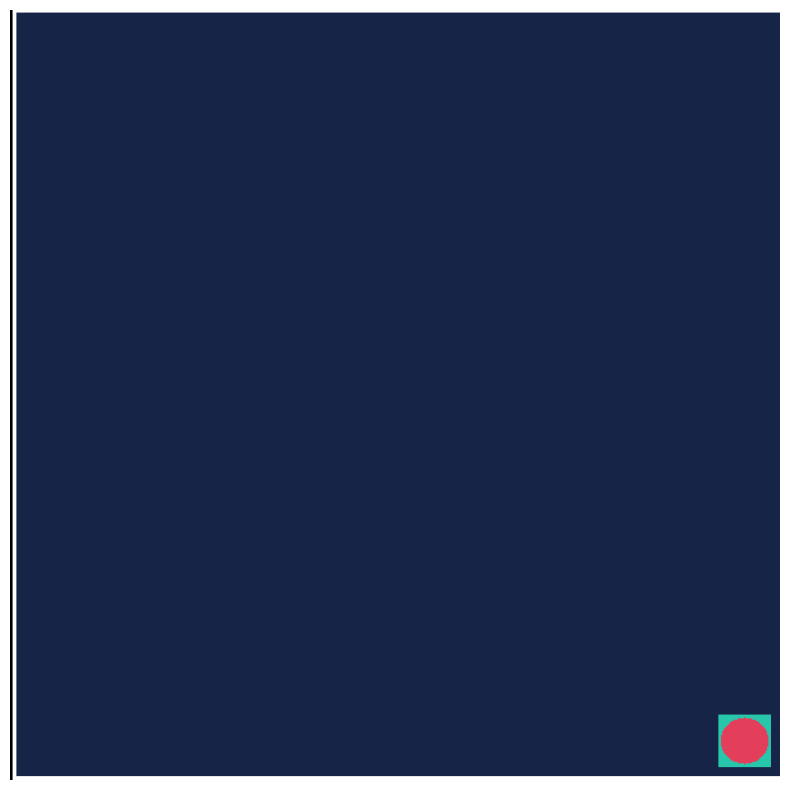

In [15]:
frame = env.render(mode='rgb_array')
plt.figure(figsize=(10,10))
plt.axis('off')
plt.imshow(frame)

In [16]:
policy_probs = np.full((10, 10, 8), 0.125)

def policy(state): 
    return policy_probs[state]

action_probabilities = policy((0,0))
for action, prob in zip(range(8), action_probabilities):
    print(f"Probability of taking action {action}: {prob}")

Probability of taking action 0: 0.125
Probability of taking action 1: 0.125
Probability of taking action 2: 0.125
Probability of taking action 3: 0.125
Probability of taking action 4: 0.125
Probability of taking action 5: 0.125
Probability of taking action 6: 0.125
Probability of taking action 7: 0.125


In [17]:
import time
inicio = time.time()
test_agent(env, policy, episodes=1)
fin = time.time()
print(fin-inicio) # 1.0005340576171875

112.41407322883606


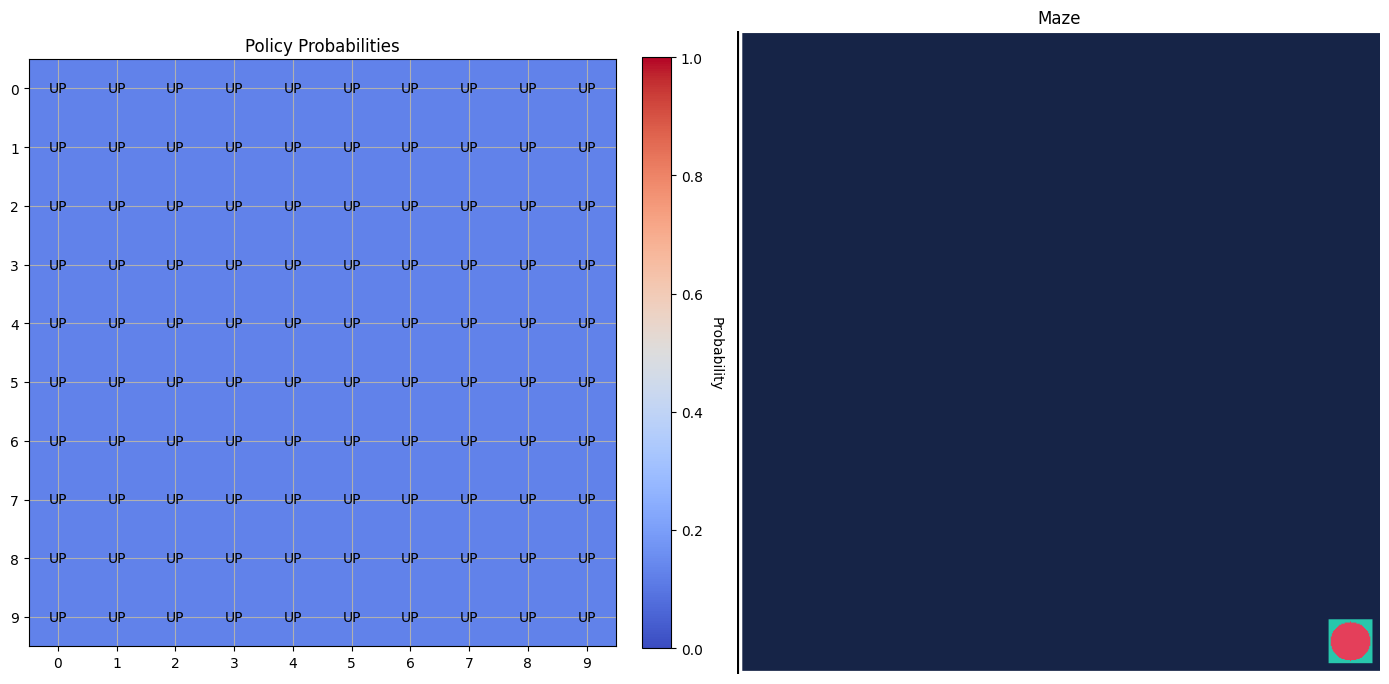

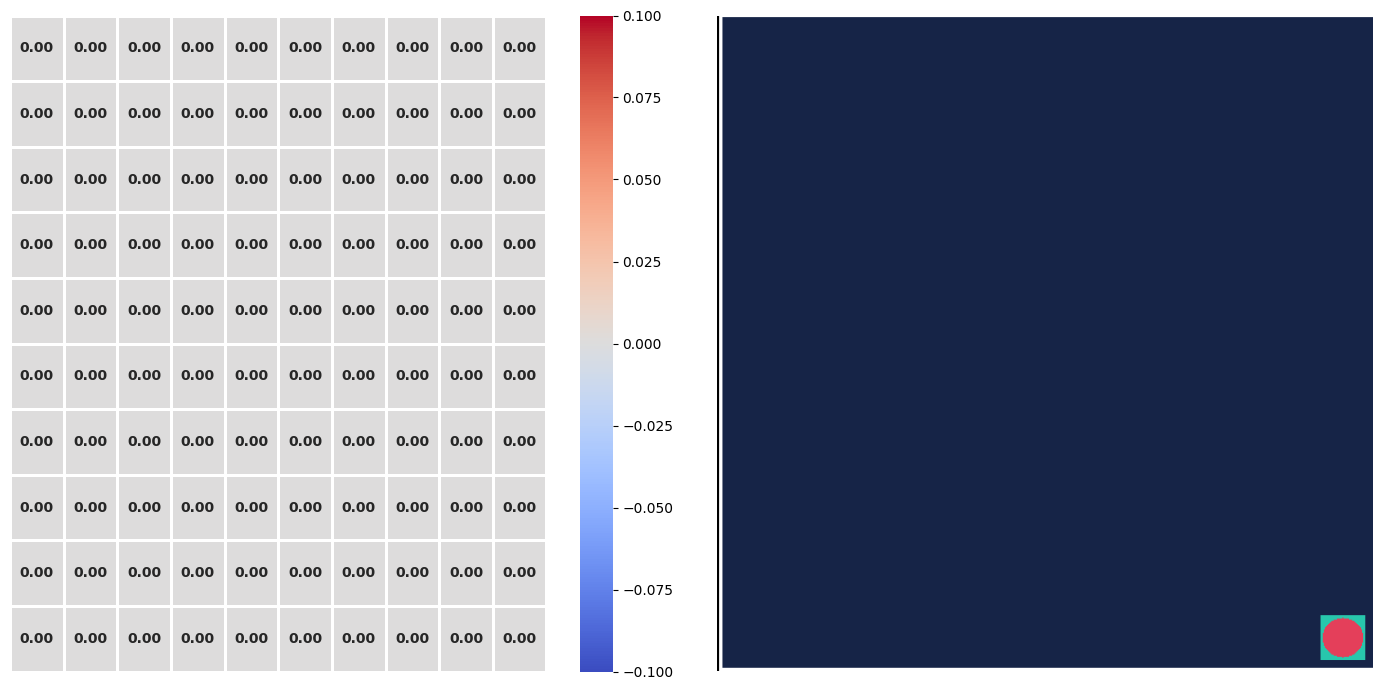

In [18]:
plot_policy(policy_probs, frame)
state_values = np.zeros(shape=(10,10))
plot_values(state_values, frame)

In [19]:
def value_iteration(policy_probs, state_values, theta=1e-6, gamma=0.99):
    rewards_per_iteration = []  # Lista para almacenar las recompensas acumuladas por iteración
    delta = float('inf')
    iteration = 0
    while delta > theta:
        delta = 0
        total_reward = 0  # Variable para almacenar la recompensa acumulada en esta iteración
        for row in range(10):
            for col in range(10):
                # Ignorar la posición del obstáculo [(1, 1), (5, 1), (8, 7)]
                ################## Aquí se agregan los obstaculos ####################################
                if (row, col) == (2, 1) or (row, col) == (4, 0) or (row, col) == (8, 1) or (row, col) == (6, 2) or (row, col) == (3, 3) or (row, col) == (4, 3) or (row, col) == (7, 3) or (row, col) == (3, 4) or (row, col) == (5, 5) or (row, col) == (6, 6) or (row, col) == (3, 1) or (row, col) == (4, 1) or (row, col) == (7, 9):
                    
                    continue

                old_value = state_values[(row, col)]
                max_qsa = float('-inf')
                q_values = np.zeros(8)

                for action in range(8):
                    next_state, reward, _, _ = env.simulate_step((row, col), action)
                    # Ignorar la recompensa si el próximo estado es el obstáculo
                    ################## Aquí se agregan los obstaculos ####################################
                    if next_state == (2, 1) or (row, col) == (4, 0) or (row, col) == (8, 1) or (row, col) == (6, 2) or (row, col) == (3, 3) or (row, col) == (4, 3) or (row, col) == (7, 3) or (row, col) == (3, 4) or (row, col) == (5, 5) or (row, col) == (6, 6) or (row, col) == (3, 1) or (row, col) == (4, 1) or (row, col) == (7, 9):
                        reward = 0  # No se recibe recompensa al pasar por el obstáculo
                    q_values[action] = reward + gamma * state_values[next_state]

                # Softmax to get action probabilities
                exp_q_values = np.exp(q_values - np.max(q_values))
                policy_probs[(row, col)] = exp_q_values / np.sum(exp_q_values)

                state_values[(row, col)] = np.max(q_values)

                delta = max(delta, abs(state_values[(row, col)] - old_value))

                total_reward += np.max(q_values)  # Acumular la recompensa para esta iteración
        
        rewards_per_iteration.append(total_reward)  # Almacenar la recompensa acumulada para esta iteración
        iteration += 1

    return rewards_per_iteration          

In [20]:
rewards_per_iteration = value_iteration(policy_probs, state_values)

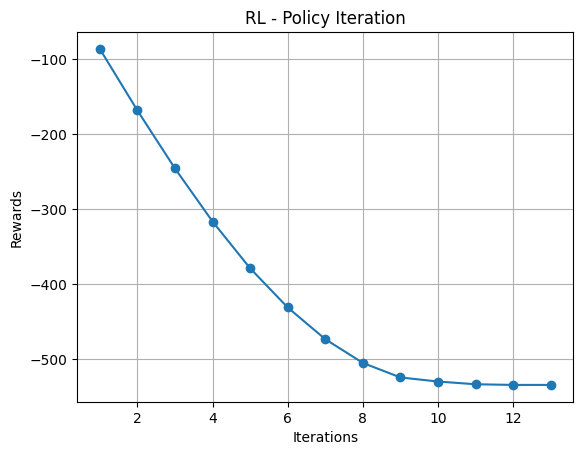

In [21]:
# Graficar iteraciones vs recompensas
iterations = list(range(1, len(rewards_per_iteration) + 1))
plt.plot(iterations, rewards_per_iteration, marker='o', linestyle='-')
plt.title('RL - Policy Iteration')
plt.xlabel('Iterations')
plt.ylabel('Rewards')
plt.grid(True)
plt.savefig('Entorno04_ivsR.png')
plt.show()


In [22]:
value_iteration(policy_probs, state_values)

[-534.601357568565]

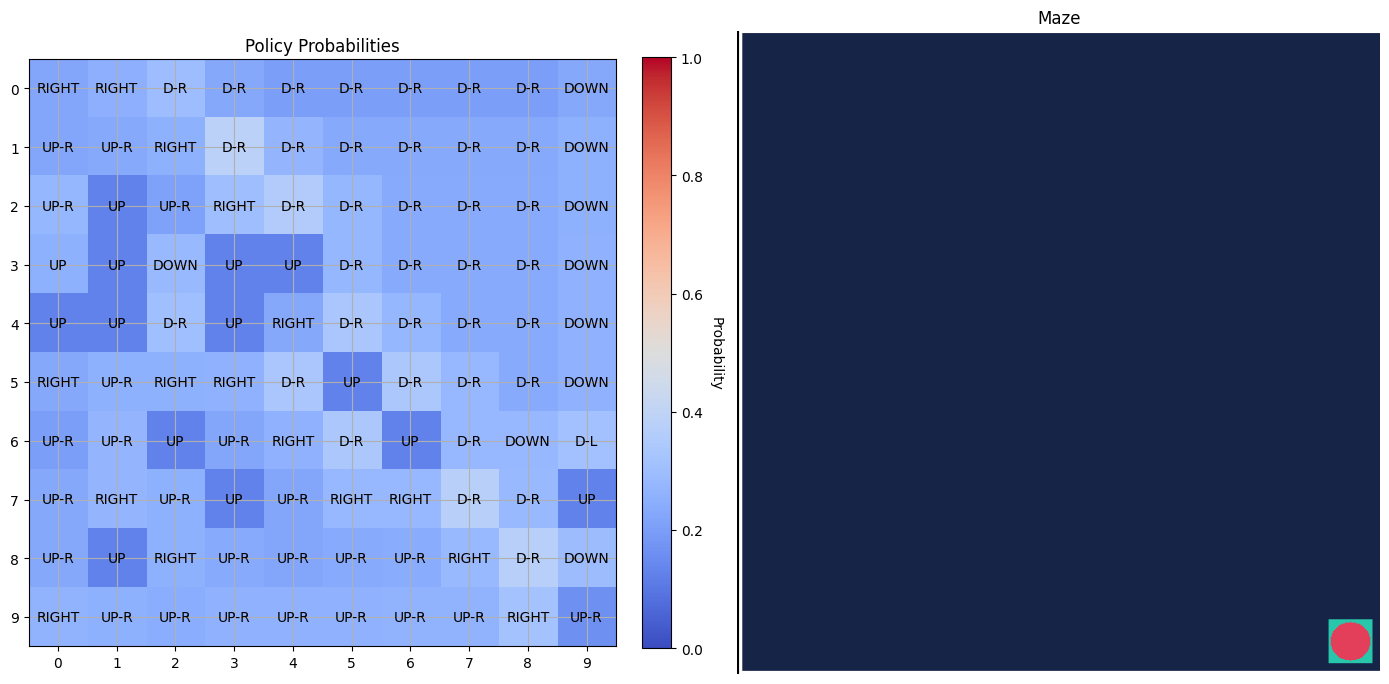

In [23]:
plot_policy(policy_probs, frame)

In [24]:
#test_agent(env, policy)